In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path
import numpy as np
import pandas as pd

from aind_hcr_data_loader.codeocean_utils import (
    MouseRecord,
    attach_mouse_record_to_workstation,
    print_attach_results,
)
from aind_hcr_data_loader.hcr_dataset import create_hcr_dataset_from_schema
from aind_hcr_data_loader.pairwise_dataset import create_pairwise_unmixing_dataset

import aind_hcr_qc.viz as viz
from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins
from aind_hcr_qc.viz.single_cell_unmixing import (
    plot_spot_projection,
    plot_spot_measure_distributions,
    plot_cell_qc,
    plot_spot_nn_distances,
    plot_adjacent_channel_scatter,
)


import aind_hcr_qc.viz.single_cell_unmixing as scu

from aind_hcr_qc.viz.spot_detection import (
    annotate_spots_df,
    plot_removal_metric_distributions,
)
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT

In [2]:
import sys, importlib
sys.path.insert(0, '/root/capsule/code/cluster_validation')
import atlas_compare
importlib.reload(atlas_compare)


<module 'atlas_compare' from '/root/capsule/code/cluster_validation/atlas_compare.py'>

In [9]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [33]:
import pandas as pd

#f1 = "/root/capsule/scratch/ref_atlas_validation/_combined_with_legacy/comparison_all.csv"
#f2 = "/root/capsule/scratch/ref_atlas_validation/_combined_with_legacy/cluster_matches_all.csv"

f1 = "/root/capsule/scratch/ref_atlas_validation/_combined/comparison_all.csv"
f2 = "/root/capsule/scratch/ref_atlas_validation/_combined/cluster_matches_all.csv"

comparison_all    = pd.read_csv(f1)
cluster_matches_all = pd.read_csv(f2)

print(f"comparison_all:     {comparison_all.shape}  mice={sorted(comparison_all.mouse_id.unique())}  filters={sorted(comparison_all.spot_filter.unique())}")
print(f"cluster_matches_all:{cluster_matches_all.shape}")


comparison_all:     (5320, 13)  mice=['755252', '755252-legacy', '767022', '767022-legacy', '782149', '782149-legacy', '788406', '788406-legacy', '790322', '790322-legacy']  filters=['all', 'valid']
cluster_matches_all:(400, 5)


# Legacy vs new comparison — multi-mouse plots

Panels are split by **filter label**: `all (new)`, `valid (new)`, `all (legacy)`, `valid (legacy)`.  
Same mouse is coloured identically across new and legacy panels.

Configure `SHOW_LEGACY` and `SPOT_FILTERS` in the cell below to control what is shown.

In [24]:
# ── Plot configuration ────────────────────────────────────────────────────────
SHOW_LEGACY  = True               # False → only new (pairwise) mice
SPOT_FILTERS = ["all", "valid"]   # subset to ["all"] or ["valid"] to show one filter only

import seaborn as sns
sns.set_context("talk")


In [36]:
# ── Annotate and filter data ──────────────────────────────────────────────────
# Adds:
#   dataset       → "new" or "legacy" (based on -legacy suffix in mouse_id)
#   base_mouse_id → mouse_id with -legacy stripped (same mouse = same colour)
#   filter_label  → e.g. "valid (new)", "all (legacy)"  — used as the panel key
#
# The existing multi-mouse functions panel by `spot_filter` and colour by
# `mouse_id`. By remapping those columns to filter_label / base_mouse_id we
# get new panels per filter×dataset combination with consistent mouse colouring.

def _annotate_legacy(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["dataset"]       = df["mouse_id"].apply(lambda x: "legacy" if str(x).endswith("-legacy") else "new")
    df["base_mouse_id"] = df["mouse_id"].astype(str).str.removesuffix("-legacy")
    df["filter_label"]  = df["spot_filter"] + " (" + df["dataset"] + ")"
    return df

_keep_datasets = ["new", "legacy"] if SHOW_LEGACY else ["new"]

comp_ann = _annotate_legacy(comparison_all)
cm_ann   = _annotate_legacy(cluster_matches_all)

comp_plot = (
    comp_ann[comp_ann["spot_filter"].isin(SPOT_FILTERS) & comp_ann["dataset"].isin(_keep_datasets)]
    .assign(mouse_id=lambda d: d["base_mouse_id"], spot_filter=lambda d: d["filter_label"])
)
cm_plot = (
    cm_ann[cm_ann["spot_filter"].isin(SPOT_FILTERS) & cm_ann["dataset"].isin(_keep_datasets)]
    .assign(mouse_id=lambda d: d["base_mouse_id"], spot_filter=lambda d: d["filter_label"])
)

print("Panels (filter_label):", sorted(comp_plot["spot_filter"].unique()))
print("Mice (base_mouse_id):", sorted(comp_plot["mouse_id"].unique()))


Panels (filter_label): ['all (legacy)', 'all (new)', 'valid (legacy)', 'valid (new)']
Mice (base_mouse_id): ['755252', '767022', '782149', '788406', '790322']


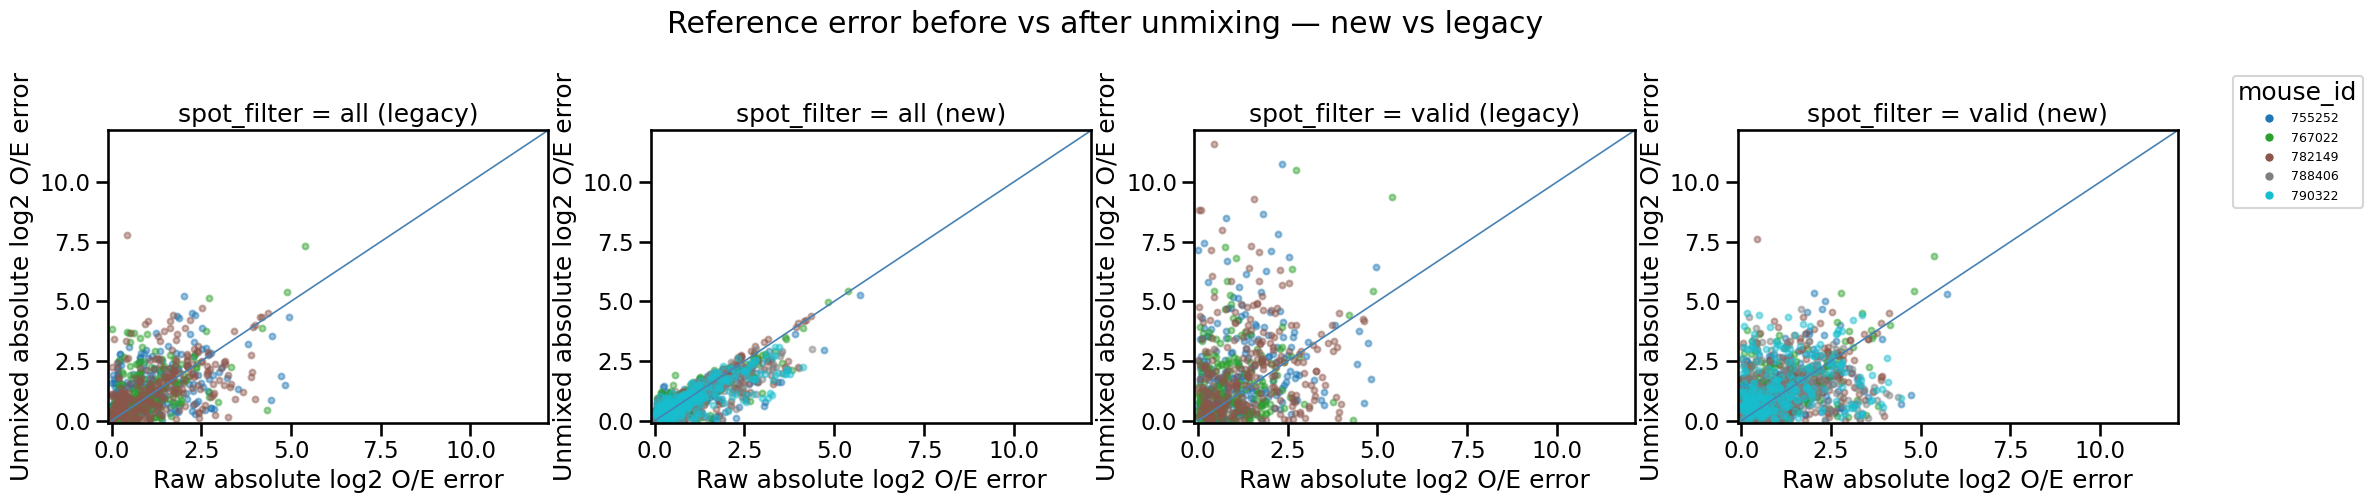

In [26]:
# Raw vs unmixed absolute error — one panel per filter label, coloured by mouse
fig = atlas_compare.plot_multi_mouse_error_improvement(
    comp_plot,
    title="Reference error before vs after unmixing — new vs legacy",
)


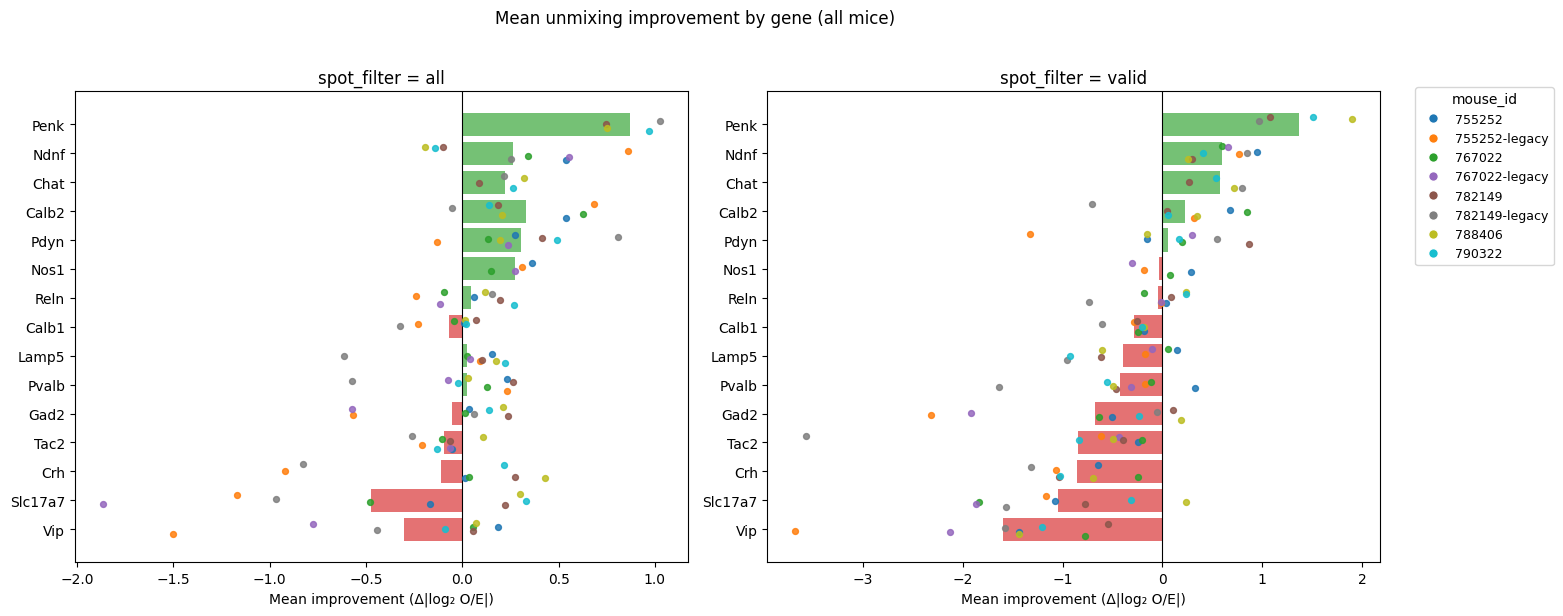

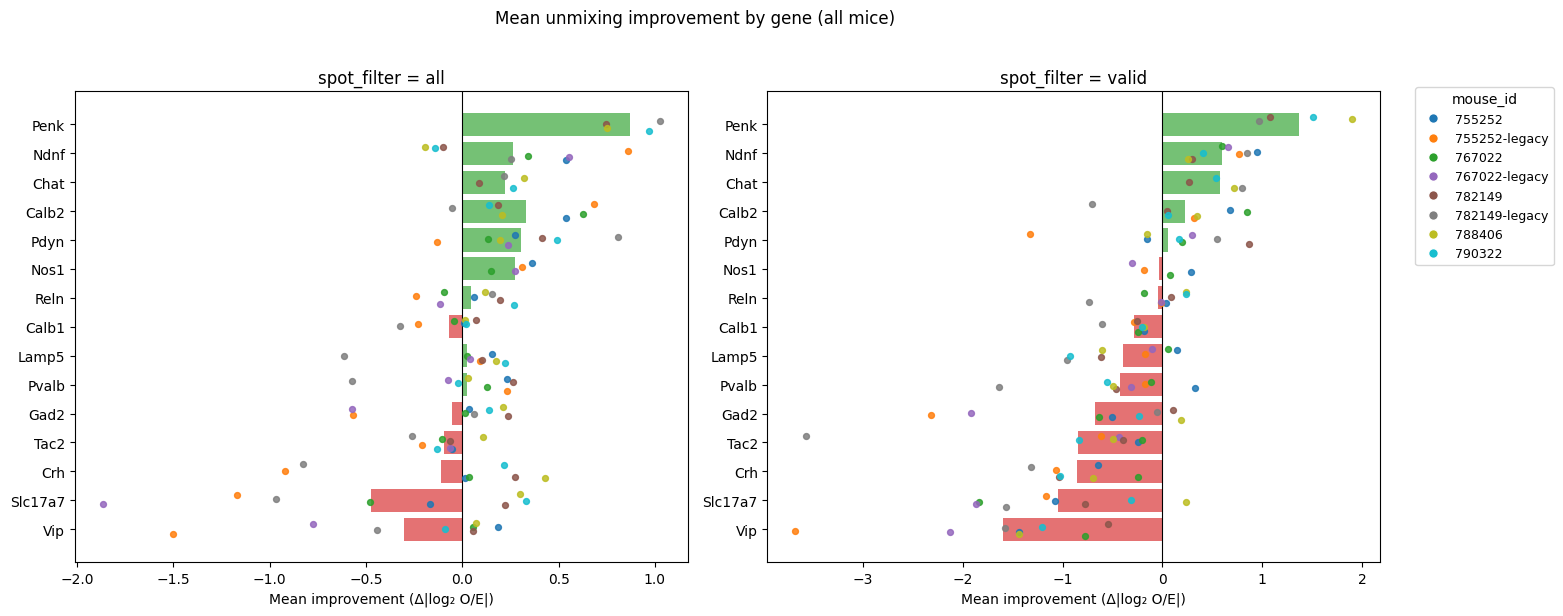

In [20]:
# Mean improvement per gene, with per-mouse dots — one panel per spot_filter
atlas_compare.plot_multi_mouse_improvement_by_gene(comparison_all)

In [19]:
# Mean improvement per gene — one panel per filter label, coloured by mouse
fig = atlas_compare.plot_multi_mouse_improvement_by_gene(
    comp_plot,
    title="Mean unmixing improvement by gene — new vs legacy",
)


Error in callback <function _draw_all_if_interactive at 0x7f312f24e340> (for post_execute), with arguments args (),kwargs {}:


ConversionError: Failed to convert value(s) to axis units: masked_array(data=[--, --, --, --, --, --, --, --, --, --, --, --, --, --,
                   --],
             mask=[ True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True],
       fill_value=1e+20,
            dtype=float64)

ConversionError: Failed to convert value(s) to axis units: masked_array(data=[--, --, --, --, --, --, --, --, --, --, --, --, --, --,
                   --],
             mask=[ True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True],
       fill_value=1e+20,
            dtype=float64)

<Figure size 2800x600 with 4 Axes>

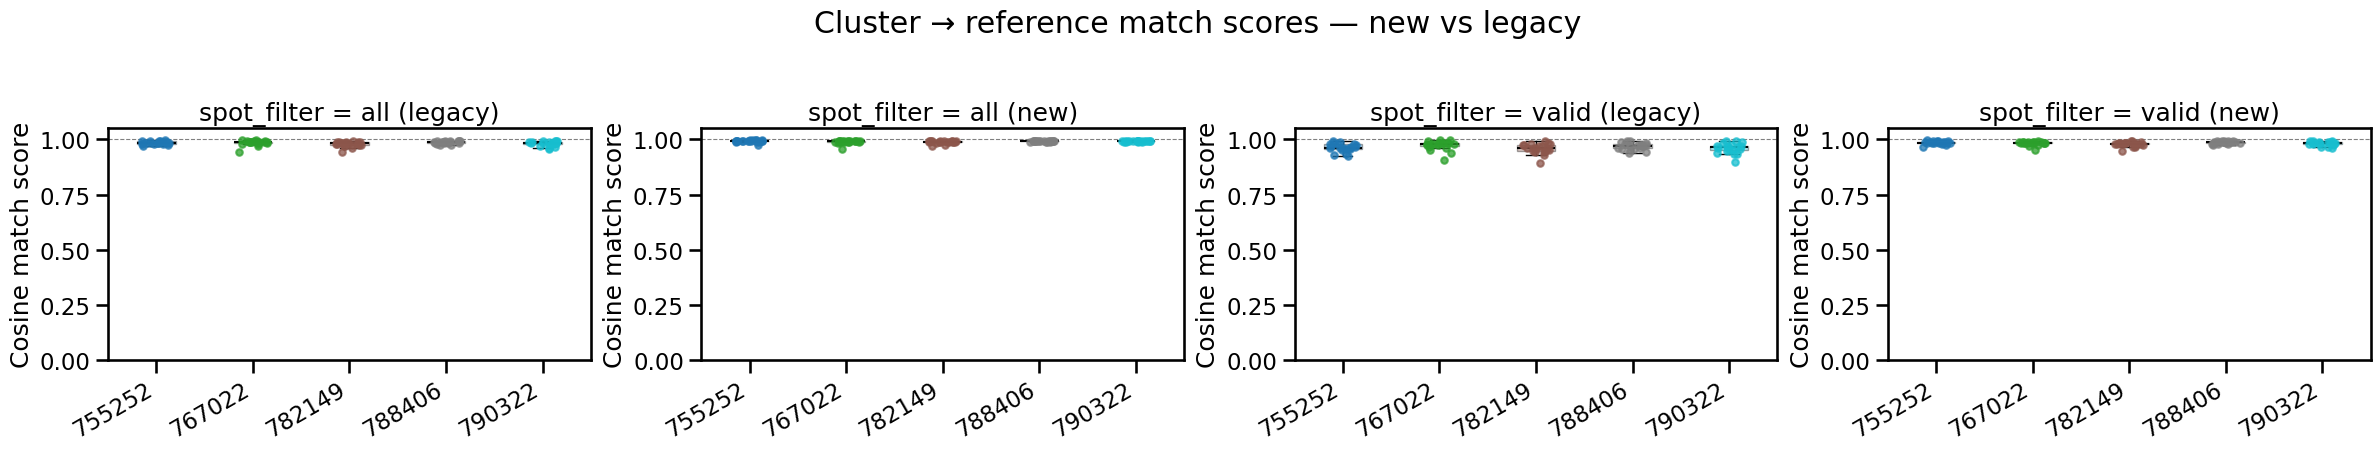

In [37]:
# Cluster → reference match score distribution — one panel per filter label
fig = atlas_compare.plot_multi_mouse_match_scores(
    cm_plot,
    title="Cluster → reference match scores — new vs legacy",
)


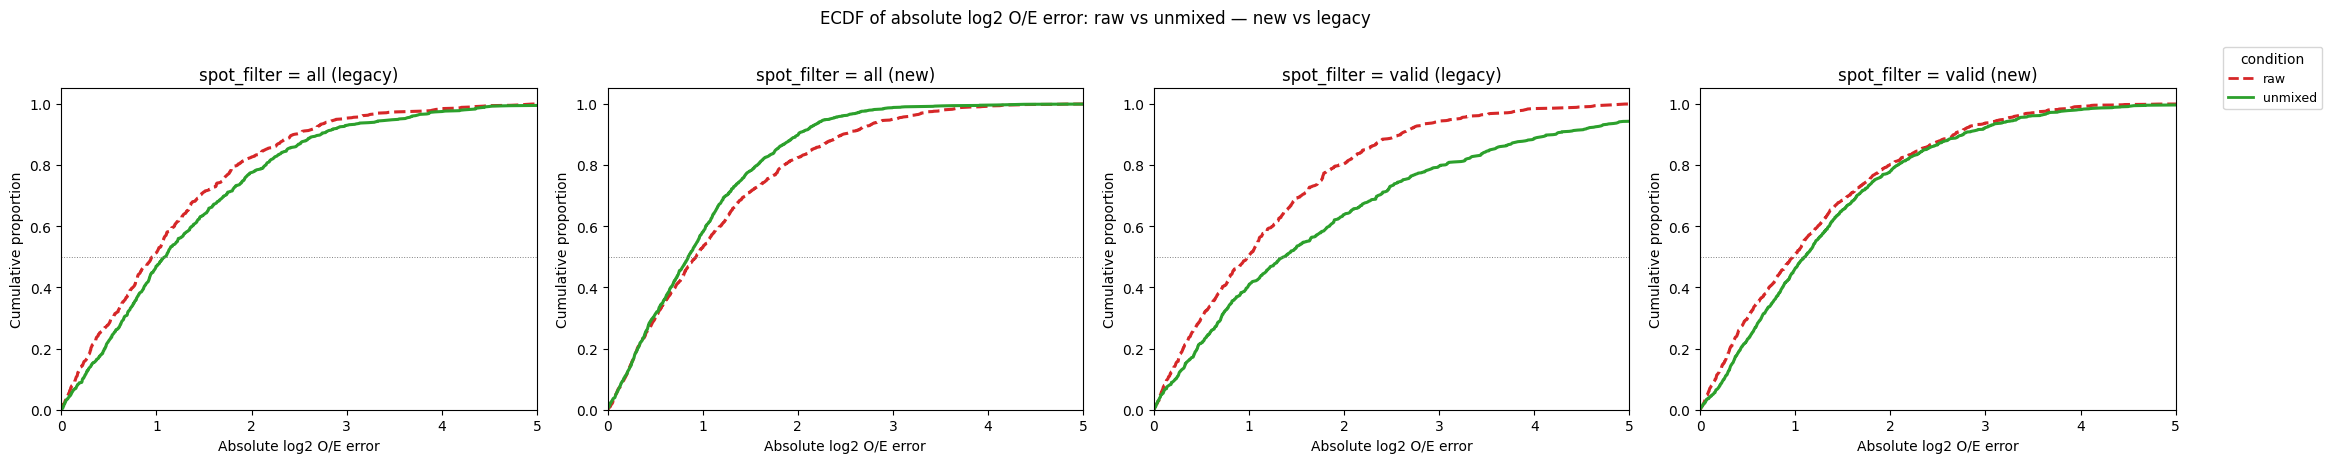

In [18]:
# ECDF raw vs unmixed — one panel per filter label (dashed=raw, solid=unmixed)
fig = atlas_compare.plot_multi_mouse_error_ecdf(
    comp_plot,
    title="ECDF of absolute log2 O/E error: raw vs unmixed — new vs legacy",
    show_individual=False
)


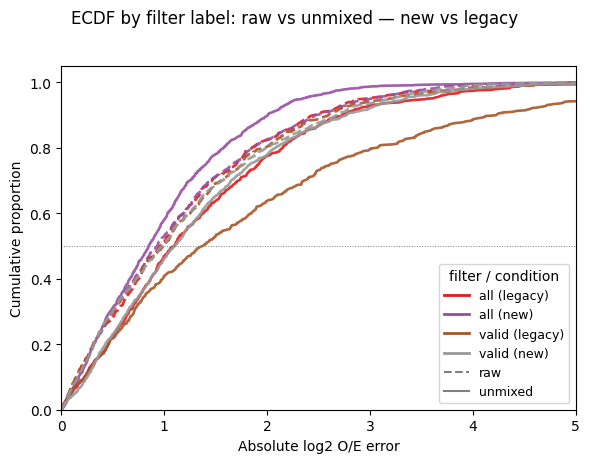

In [17]:
# ECDF by filter label — all filter×dataset combinations in one panel
# Each colour = one filter_label; dashed = raw, solid = unmixed
fig = atlas_compare.plot_multi_mouse_filter_ecdf(
    comp_plot,
    title="ECDF by filter label: raw vs unmixed — new vs legacy",
)


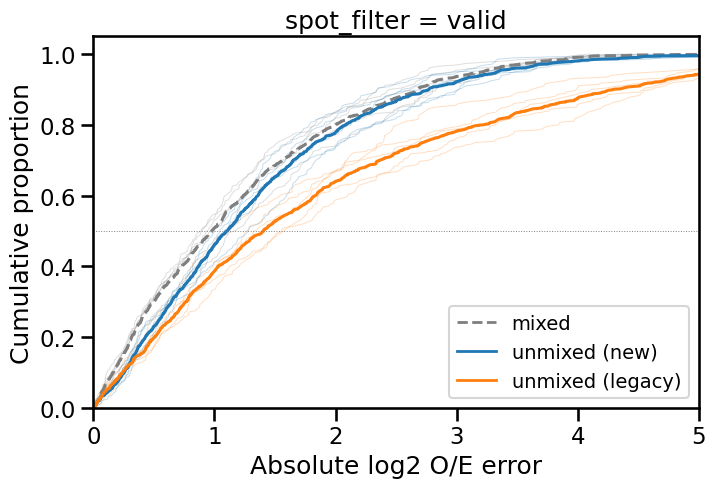

In [42]:

fig = atlas_compare.plot_legacy_vs_new_ecdf(
    comp_ann,
    spot_filter="valid",
    title = None,
    show_individual=True,
    figsize=(7.5, 5.5)
)


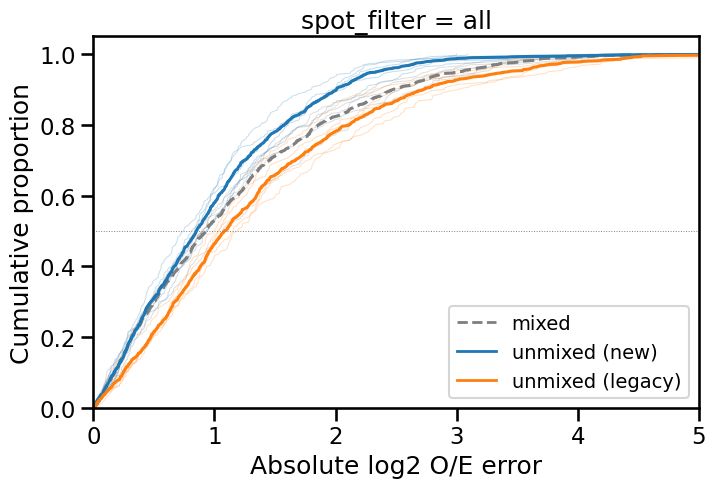

In [43]:
# Legacy vs new — single raw + two unmixed ECDFs, spot_filter="valid"
fig = atlas_compare.plot_legacy_vs_new_ecdf(
    comp_ann,
    spot_filter="all",
    title=None,
    show_individual=True,
    figsize=(7.5, 5.5)
)
